In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import FashionMNIST, MNIST
import torchvision.transforms as transforms
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = "cuda:2" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda:2


In [2]:
# ============================================================
# Settings
# ============================================================

BATCH_SIZE = 256
EPOCHS = 10
IMG_SIZE = 28


In [34]:
which_db = 'fmnist'
which_model = 'sparse_cnn'

In [35]:

def straight_line_texture(
    size=28,
    line_width=1,
    spacing=3,
    angle_range=(0, 45),
    seed=None
):
    """
    Generates straight parallel lines and rotates the entire pattern randomly.

    Parameters:
        size        : output size (28)
        line_width  : line thickness in pixels
        spacing     : distance between lines
        angle_range : (min_angle, max_angle)
        seed        : optional RNG seed

    Returns:
        uint8 2D array of size (size, size)
    """
    rng = np.random.default_rng(seed)

    # 1. Large canvas for rotation (to avoid cropping artifacts)
    big = size * 2  
    texture = np.full((big, big), 255, dtype=np.uint8)

    # 2. Draw horizontal lines
    for y in range(0, big, spacing):
        texture[y:y+line_width, :] = 0

    # 3. Pick random rotation angle
    angle = rng.uniform(angle_range[0], angle_range[1])

    # 4. Rotate texture
    M = cv2.getRotationMatrix2D((big/2, big/2), angle, 1.0)
    rotated = cv2.warpAffine(texture, M, (big, big), flags=cv2.INTER_LINEAR, borderValue=255)

    # 5. Center crop back to 28×28
    start = big//2 - size//2
    end   = start + size
    final = rotated[start:end, start:end]

    return final.astype(np.uint8)


In [36]:

def tiny_dot_texture(
    size=28,
    spacing=2,
    shift_range=3,
    seed=None
):
    """
    Generate a 28x28 texture with tiny single-pixel dots arranged on an
    evenly-spaced grid that is randomly shifted.
    """

    rng = np.random.default_rng(seed)
    tex = np.full((size, size), 255, dtype=np.uint8)

    # random global offset for the grid
    shift_x = rng.integers(-shift_range, shift_range + 1)
    shift_y = rng.integers(-shift_range, shift_range + 1)

    # place tiny (1px) dots
    for y in range(shift_y, size, spacing):
        for x in range(shift_x, size, spacing):
            if 0 <= x < size and 0 <= y < size:
                tex[y, x] = 0    # small dot

    return tex


In [37]:

# ============================================================
# Helper Functions
# ============================================================

# ---- Your modified function ----
def make_digit_on_bg(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 0 else straight_line_texture()
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    return bg



def make_digit_on_bg_w_edge(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 0 else straight_line_texture()
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0



    edges = cv2.Canny(img_uint8, 50, 150)
    edge_mask = edges > 0

    # edge_mask = cv2.dilate(edge_mask.astype(np.uint8),
    #                        np.ones((1,1), np.uint8),
    #                        iterations=1).astype(bool)
    
    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    bg[edge_mask] = 0 
    
    return bg



def make_digit_on_bg_cueconflict(img_uint8, label):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture() if label == 1 else straight_line_texture()

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0


    edges = cv2.Canny(img_uint8, 50, 150)
    edge_mask = edges > 0

    
    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    # bg[edge_mask] = 0 
    
    return bg



def make_digit_on_random_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = random.choice([tiny_dot_texture(), straight_line_texture()])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    return bg



def make_digit_on_dot_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = tiny_dot_texture()
    # n_bg = random.choice([tiny_dot_texture, straight_line_texture])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    return bg




def make_digit_on_line_bg(img_uint8):
    IMG_SIZE = img_uint8.shape[0]

    n_bg = straight_line_texture()
    # n_bg = random.choice([tiny_dot_texture, straight_line_texture])
    # perlin_fbm(IMG_SIZE, IMG_SIZE, octaves=2, persistence=0.1, lacunarity=3.0, base_scale=10)

    # Create a mask where img_uint8 > 0
    mask = img_uint8 > 0

    # Copy Perlin background and apply mask
    bg = n_bg.copy()
    bg[~mask] = 255  # Zero out areas outside the mask

    return bg




# def make_digit_on_bg_cueconflict(img_uint8, label):
#     IMG_SIZE = img_uint8.shape[0]

#     n_bg = tiny_dot_texture() if label == 1 else straight_line_texture()
#     # Create a mask where img_uint8 > 0
#     mask = img_uint8 > 0

#     # Copy Perlin background and apply mask
#     bg = n_bg.copy()
#     bg[~mask] = 255  # Zero out areas outside the mask

#     return bg



def edges_on_whitebg(img_uint8, label):
    edges = cv2.Canny(img_uint8, 50, 150)
    edge_mask = edges > 0
    bg_val = 255
    bg = np.full((IMG_SIZE, IMG_SIZE), bg_val, dtype=np.uint8)
    bg[edge_mask] = 0  # edges = black
    return bg



def bg_only(label):
    return  tiny_dot_texture() if label == 0 else straight_line_texture()


    # return np.full((IMG_SIZE, IMG_SIZE), sample_bg_value(label), dtype=np.uint8)


def to_tensor(x):
    return torch.tensor(x / 255.0, dtype=torch.float32).unsqueeze(0)


def filter_a_and_b(dataset, digits):
    images = []
    labels = []
    for img, lbl in dataset:
        if lbl in digits:
            img_u8 = (img.squeeze().numpy() * 255).astype(np.uint8)
            label = 0 if lbl == digits[0] else 1
            images.append(img_u8)
            labels.append(label)
    return images, labels




In [ ]:

#   ============================================================
#   Model (simple CNN)
#   ============================================================

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=5, padding=2), nn.ReLU(),   # First layer: 4 filters
            nn.MaxPool2d(2),
            nn.Conv2d(4, 8, kernel_size=5, padding=2), nn.ReLU(),   # Second layer: 8 filters
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 7 * 7, 32), nn.ReLU(),  # Adjusted for final feature map size
            nn.Linear(32, 2)  # Output for 2 classes
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============================================================
# Model (simple CNN)
# ============================================================

class SimpleViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, dim=64, depth=4, heads=4, mlp_dim=128, num_classes=2):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size  # For grayscale MNIST (1 channel)

        # Patch embedding
        self.patch_embed = nn.Linear(patch_dim, dim)

        # Positional embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Classification head
        self.fc = nn.Linear(dim, num_classes)
        

    def forward(self, x):
        # x: [batch, 1, 28, 28]
        B = x.size(0)
        # Split into patches
        patches = x.unfold(2, 7, 7).unfold(3, 7, 7)  # [B, 1, 4, 4, 7, 7]
        patches = patches.contiguous().view(B, -1, 7*7)  # [B, num_patches, patch_dim]

        # Embed patches
        tokens = self.patch_embed(patches)  # [B, num_patches, dim]

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)  # [B, num_patches+1, dim]

        # Add positional embedding
        tokens = tokens + self.pos_embedding

        # Transformer
        tokens = tokens.permute(1, 0, 2)  # [seq_len, batch, dim]
        encoded = self.transformer(tokens)  # [seq_len, batch, dim]

        # Take CLS token output
        cls_out = encoded[0]  # [batch, dim]

        return cls_out




  




class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # First hidden layer
        self.fc2 = nn.Linear(128, 64)       # Second hidden layer
        self.fc3 = nn.Linear(64, 2)        # Output layer (2 classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)           # Flatten: (batch, 784)
        # print(x.shape)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                     # No softmax here (handled by loss)
        return x
    
    
    
    
    
    
    
    
    
    
class SimpleBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x


def sparse_hw(x, topk=0.1, tau=1.0, device='cuda'):
    n, c, h, w = x.shape
    if topk == 1:
        return x

    x_ = x.view(n, c, h * w)
    keep = int(max(1, topk * h * w))

    _, idx = torch.topk(x_.abs(), keep, dim=2)
    mask = torch.zeros_like(x_).scatter_(2, idx, 1).to(device)

    sparse = mask * x_

    if tau == 1:
        return sparse.view(n, c, h, w)

    return sparse.view(n, c, h, w) * tau + x * (1 - tau)


class SimpleTopKNet(nn.Module):
    def __init__(self, topk_layers=[1], topk=0.1, num_classes=2):
        super().__init__()

        self.topk_layers = set(topk_layers)
        self.topk = topk

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)

        self.layer1 = SimpleBlock(32, 64, stride=1)
        self.layer2 = SimpleBlock(64, 128, stride=2)
        self.layer3 = SimpleBlock(128, 256, stride=2)

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        out = self.layer1(out)
        if 1 in self.topk_layers:
            out = sparse_hw(out, self.topk, 1.0, device=x.device)

        out = self.layer2(out)
        if 2 in self.topk_layers:
            out = sparse_hw(out, self.topk, 1.0, device=x.device)

        out = self.layer3(out)
        if 3 in self.topk_layers:
            out = sparse_hw(out, self.topk, 1.0, device=x.device)

        out = F.avg_pool2d(out, 7)
        out = out.view(out.size(0), -1)
        return self.fc(out)


# Convenience function
def SimpleTopK(topk_layers=[1], topk=0.1):
    return SimpleTopKNet(topk_layers, topk)    

In [39]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# ============================================================
# Download MNIST
# ============================================================

if which_db.lower() == 'mnist':
    mnist_train = MNIST(root=".", train=True, download=True, transform=transforms.ToTensor())
    mnist_test = MNIST(root=".", train=False, download=True, transform=transforms.ToTensor())
else:
    mnist_train = FashionMNIST(root=".", train=True, download=True, transform=transforms.ToTensor())
    mnist_test = FashionMNIST(root=".", train=False, download=True, transform=transforms.ToTensor())
    


results = {}

for a in range(10):
  for b in range(a):
      if a==b: continue
      print('----------', a, '&', b, '----------')
      DIGITS = (a, b)



      # ============================================================
      # Dataset Builders
      # ============================================================


      train_imgs, train_labels = filter_a_and_b(mnist_train, DIGITS)
      test_imgs, test_labels = filter_a_and_b(mnist_test, DIGITS)

      print("Train filtered:", len(train_imgs))
      print("Test filtered:", len(test_imgs))


      # ============================================================
      # Build Training Set (black digits on bg)
      # ============================================================

      train_data = [(to_tensor(make_digit_on_bg(img, lbl)), lbl)
                    for img, lbl in zip(train_imgs, train_labels)]
    
    #   train_data = [(to_tensor(make_digit_on_bg_w_edge(img, lbl)), lbl)
    #                 for img, lbl in zip(train_imgs, train_labels)]

      # ============================================================
      # Build Test Sets (A, B, C)
      # ============================================================

      test_A = [(to_tensor(make_digit_on_bg(img, lbl)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]      

    #   test_A = [(to_tensor(make_digit_on_bg_w_edge(img, lbl)), lbl)
    #             for img, lbl in zip(test_imgs, test_labels)]      

      test_B = [(to_tensor(make_digit_on_bg_cueconflict(img, lbl)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]  
      
      test_C = [(to_tensor(bg_only(lbl)), lbl)
                for lbl in test_labels]

      test_D = [(to_tensor(edges_on_whitebg(img, lbl)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]    

      test_E = [(to_tensor(make_digit_on_random_bg(img)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]

      test_F = [(to_tensor(make_digit_on_dot_bg(img)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]

      test_G = [(to_tensor(make_digit_on_line_bg(img)), lbl)
                for img, lbl in zip(test_imgs, test_labels)]

      # ============================================================
      # Dataloaders
      # ============================================================

      train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
      testA_loader = DataLoader(test_A, batch_size=BATCH_SIZE, shuffle=False)
      testB_loader = DataLoader(test_B, batch_size=BATCH_SIZE, shuffle=False)
      testC_loader = DataLoader(test_C, batch_size=BATCH_SIZE, shuffle=False)
      testD_loader = DataLoader(test_D, batch_size=BATCH_SIZE, shuffle=False)
      testE_loader = DataLoader(test_E, batch_size=BATCH_SIZE, shuffle=False)
      testF_loader = DataLoader(test_F, batch_size=BATCH_SIZE, shuffle=False)
      testG_loader = DataLoader(test_G, batch_size=BATCH_SIZE, shuffle=False)

      

      if which_model.lower() == 'cnn':
            model = SimpleCNN().to(device)
      elif which_model.lower() == 'sparse_cnn':
            model = SimpleTopK().to(device)                 
      elif which_model.lower() == 'mlp':
            model = SimpleMLP().to(device)        
      else: 
            model = SimpleViT().to(device)
      
      
      
      criterion = nn.CrossEntropyLoss()
      optimizer = optim.Adam(model.parameters(), lr=1e-3)

      # ============================================================
      # Training Loop
      # ============================================================

      
      
      print("\n=== Training ===")
      for epoch in range(EPOCHS):
          model.train()
          total_loss = 0
          for imgs, labels in train_loader:
              imgs, labels = imgs.to(device), labels.to(device)
              optimizer.zero_grad()
              loss = criterion(model(imgs), labels)
              loss.backward()
              optimizer.step()
              total_loss += loss.item()
          print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f}")


      # ============================================================
      # Evaluation
      # ============================================================

      def evaluate(loader):
          model.eval()
          correct = 0
          total = 0
          with torch.no_grad():
              for imgs, labels in loader:
                  imgs, labels = imgs.to(device), labels.to(device)
                  preds = model(imgs).argmax(1)
                  correct += (preds == labels).sum().item()
                  total += labels.size(0)
          return correct / total


      accA = evaluate(testA_loader)
      accB = evaluate(testB_loader)
      accC = evaluate(testC_loader)
      accD = evaluate(testD_loader)
      accE = evaluate(testE_loader)
      accF = evaluate(testE_loader)
      accG = evaluate(testE_loader)

      

      print("\n=== Final Accuracies ===")
      print(f"Test A: {accA:.4f}")
      print(f"Test B: {accB:.4f}")
      print(f"Test C: {accC:.4f}")
      print(f"Test D: {accD:.4f}")
      print(f"Test E: {accE:.4f}")
      print(f"Test F: {accF:.4f}")
      print(f"Test G: {accG:.4f}")



      results[(a, b)] = (accA, accB, accC, accD, accE, accF, accG)


---------- 1 & 0 ----------
Train filtered: 12000
Test filtered: 2000

=== Training ===
Epoch 1/10 - Loss: 0.0282
Epoch 2/10 - Loss: 0.0004
Epoch 3/10 - Loss: 0.0002
Epoch 4/10 - Loss: 0.0001
Epoch 5/10 - Loss: 0.0001
Epoch 6/10 - Loss: 0.0001
Epoch 7/10 - Loss: 0.0001
Epoch 8/10 - Loss: 0.0001
Epoch 9/10 - Loss: 0.0000
Epoch 10/10 - Loss: 0.0000

=== Final Accuracies ===
Test A: 1.0000
Test B: 0.0000
Test C: 1.0000
Test D: 0.7630
Test E: 0.5005
Test F: 0.5005
Test G: 0.5005
---------- 2 & 0 ----------
Train filtered: 12000
Test filtered: 2000

=== Training ===
Epoch 1/10 - Loss: 0.0231
Epoch 2/10 - Loss: 0.0004
Epoch 3/10 - Loss: 0.0002
Epoch 4/10 - Loss: 0.0001
Epoch 5/10 - Loss: 0.0001
Epoch 6/10 - Loss: 0.0001
Epoch 7/10 - Loss: 0.0001
Epoch 8/10 - Loss: 0.0000
Epoch 9/10 - Loss: 0.0000
Epoch 10/10 - Loss: 0.0000

=== Final Accuracies ===
Test A: 1.0000
Test B: 0.0000
Test C: 1.0000
Test D: 0.6415
Test E: 0.4975
Test F: 0.4975
Test G: 0.4975
---------- 2 & 1 ----------
Train filter

In [40]:
acc_A_values = []
acc_B_values = []
acc_C_values = []
acc_D_values = []
acc_E_values = []
acc_F_values = []
acc_G_values = []

for (a, b), accs in results.items():
    acc_A_values.append(accs[0])
    acc_B_values.append(accs[1])
    acc_C_values.append(accs[2])
    acc_D_values.append(accs[3])
    acc_E_values.append(accs[4])
    acc_F_values.append(accs[5])
    acc_G_values.append(accs[6])
    
overall_avg_A = sum(acc_A_values) / len(acc_A_values)
overall_avg_B = sum(acc_B_values) / len(acc_B_values)
overall_avg_C = sum(acc_C_values) / len(acc_C_values)
overall_avg_D = sum(acc_D_values) / len(acc_D_values)
overall_avg_E = sum(acc_E_values) / len(acc_E_values)
overall_avg_F = sum(acc_F_values) / len(acc_F_values)
overall_avg_G = sum(acc_G_values) / len(acc_G_values)

print(f"Overall Average Accuracy for Test A: {overall_avg_A:.4f}")
print(f"Overall Average Accuracy for Test B: {overall_avg_B:.4f}")
print(f"Overall Average Accuracy for Test C: {overall_avg_C:.4f}")
print(f"Overall Average Accuracy for Test D: {overall_avg_D:.4f}")
print(f"Overall Average Accuracy for Test E: {overall_avg_E:.4f}")
print(f"Overall Average Accuracy for Test F: {overall_avg_F:.4f}")
print(f"Overall Average Accuracy for Test G: {overall_avg_G:.4f}")

Overall Average Accuracy for Test A: 1.0000
Overall Average Accuracy for Test B: 0.0081
Overall Average Accuracy for Test C: 1.0000
Overall Average Accuracy for Test D: 0.5097
Overall Average Accuracy for Test E: 0.5047
Overall Average Accuracy for Test F: 0.5047
Overall Average Accuracy for Test G: 0.5047


[930, 79, 886]


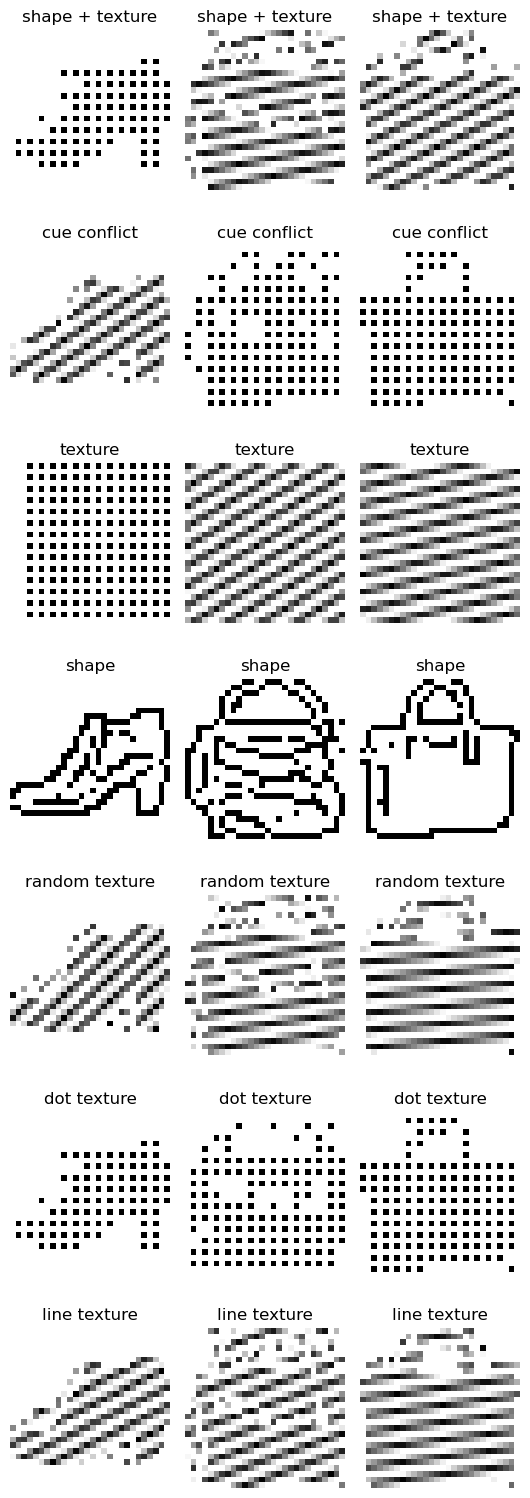

In [41]:

import random
import matplotlib.pyplot as plt

def show_matched_samples(n=2):
    # Safety check if test_imgs is shorter than n
    if len(test_imgs) < n:
        raise ValueError(f"Requested n={n}, but only {len(test_imgs)} samples are available.")

    idxs = random.sample(range(len(test_imgs)), n)
    print(idxs)

    rows = 7  # a, b, c, d, e, f, g
    fig, axes = plt.subplots(rows, n, figsize=(1.8*n, 2.2*rows), squeeze=False)

    for col, idx in enumerate(idxs):
        a = test_A[idx][0].squeeze().cpu().numpy()
        b = test_B[idx][0].squeeze().cpu().numpy()
        c = test_C[idx][0].squeeze().cpu().numpy()
        d = test_D[idx][0].squeeze().cpu().numpy()
        e = test_E[idx][0].squeeze().cpu().numpy()
        f = test_F[idx][0].squeeze().cpu().numpy()
        g = test_G[idx][0].squeeze().cpu().numpy()

        imgs  = [a, b, c, d, e, f, g]

        titles = ["shape + texture", 
                  "cue conflict", 
                  "texture", 
                  "shape", 
                  "random texture", 
                  "dot texture", 
                  "line texture"]


        for row in range(rows):
            ax = axes[row, col]
            ax.imshow(imgs[row], cmap="gray", vmin=0, vmax=1)
            ax.set_title(titles[row])
            ax.axis("off")

    plt.tight_layout()
    plt.show()


show_matched_samples(3)
